In [ ]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP
# Install required libraries for fine-tuning TinyLlama on Colab
# ============================================================
!pip install -q --upgrade transformers datasets accelerate peft bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# SECTION 2: IMPORTS & REPRODUCIBILITY CONFIGURATION
# Load all necessary libraries and fix random seeds
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time
import gc
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Print hardware information
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version  : 2.10.0+cu128
CUDA available   : True
GPU device       : Tesla T4
GPU memory       : 15.64 GB


In [ ]:
# ============================================================
# SECTION 3: DATASET LOADING
# Load the Stanford IMDB movie-review dataset (binary sentiment)
# No authentication token required – dataset is publicly available
# ============================================================

print("Loading IMDB dataset from Hugging Face Datasets hub...")
dataset = load_dataset("imdb")

print("\nDataset overview:")
print(f"  Train samples : {len(dataset['train'])}")
print(f"  Test  samples : {len(dataset['test'])}")
print("\nSample record:")
print(dataset['train'][0])

Loading IMDB dataset from Hugging Face Datasets hub...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset overview:
  Train samples : 25000
  Test  samples : 25000

Sample record:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, thi

In [ ]:
# ============================================================
# SECTION 4: DATASET SPLITTING
# Create train / validation / test subsets
# Using a manageable subset suitable for Colab free-tier GPU
# ============================================================

# Subsample to keep runtimes feasible on Colab T4/A100
train_data = dataset['train'].shuffle(seed=SEED).select(range(1000))
test_data  = dataset['test'].shuffle(seed=SEED).select(range(500))

# Create an 80/20 train-validation split from the training subset
split = train_data.train_test_split(test_size=0.2, seed=SEED)
train_dataset = split['train']
val_dataset   = split['test']

print(f"Training   samples : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test       samples : {len(test_data)}")

# Verify class balance in the training split
train_labels = [item['label'] for item in train_dataset]
print("\nLabel distribution in training split:")
print(f"  Negative (0) : {train_labels.count(0)}")
print(f"  Positive (1) : {train_labels.count(1)}")

Training   samples : 800
Validation samples : 200
Test       samples : 500

Label distribution in training split:
  Negative (0) : 406
  Positive (1) : 394


In [ ]:
# ============================================================
# SECTION 5: MODEL & TOKENIZER CONFIGURATION
# Base model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
# Publicly available – no Hugging Face token required
# 4-bit NF4 quantisation to fit comfortably in Colab GPU VRAM
# ============================================================

BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# 4-bit quantisation config (QLoRA setup)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load the tokeniser for TinyLlama
print(f"Loading tokeniser for {BASE_MODEL_ID} ...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokeniser loaded successfully.")
print(f"Vocabulary size : {len(tokenizer):,}")

Loading tokeniser for TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Tokeniser loaded successfully.
Vocabulary size : 32,000


In [ ]:
# ============================================================
# SECTION 6: PROMPT FORMATTING
# TinyLlama uses the ChatML-style template:
#   <|system|>...</s>\n<|user|>...</s>\n<|assistant|>\n...
# All dataset splits are converted to this instruction format
# ============================================================

SYSTEM_MSG = (
    "You are a sentiment analysis assistant. "
    "Classify the sentiment of each movie review as either 'positive' or 'negative'."
)

def format_instruction(sample):
    """Convert a raw IMDB sample into TinyLlama chat-template format."""
    review     = sample['text'][:500]           # truncate to 500 chars for memory
    label_text = "positive" if sample['label'] == 1 else "negative"

    prompt = (
        f"<|system|>\n{SYSTEM_MSG}</s>\n"
        f"<|user|>\nReview: {review}</s>\n"
        f"<|assistant|>\nSentiment: {label_text}</s>"
    )
    return {"formatted_text": prompt}

print("Applying prompt template to all dataset splits...")
train_dataset = train_dataset.map(format_instruction)
val_dataset   = val_dataset.map(format_instruction)
test_data     = test_data.map(format_instruction)

print("\nFormatted prompt example (first training sample):")
print(train_dataset[0]['formatted_text'][:600])

Applying prompt template to all dataset splits...


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Formatted prompt example (first training sample):
<|system|>
You are a sentiment analysis assistant. Classify the sentiment of each movie review as either 'positive' or 'negative'.</s>
<|user|>
Review: I saw this many years after the television series and, initially, I didn't care for it. Then, as my memory of the series receded with the passage of time, I watched again, and found it absolutely hilarious. Based on the stage play by Neil Simon, it has not been 'opened out' much for the big screen, and that's one of its strengths. Walter Matthau and Jack Lemmon are brilliant as Oscar and Felix, and the supporting cast are wonderful, particularl


In [ ]:
# ============================================================
# SECTION 7: EVALUATION HELPER FUNCTION
# Runs the model over 'test_dataset' and computes
# Accuracy, Precision, Recall, and F1-score
# ============================================================

def evaluate_model(model, tokenizer, test_dataset, model_label="Model"):
    """Evaluate a causal-LM on binary sentiment classification."""
    print(f"\n--- Evaluating: {model_label} ---")
    predictions = []
    true_labels = []

    model.eval()
    start_time = time.time()

    for i, sample in enumerate(test_dataset):
        if i % 50 == 0:
            print(f"  Progress: {i}/{len(test_dataset)} samples")

        review = sample['text'][:500]

        # Build the inference prompt (no assistant completion)
        inference_prompt = (
            f"<|system|>\n{SYSTEM_MSG}</s>\n"
            f"<|user|>\nReview: {review}</s>\n"
            f"<|assistant|>\nSentiment:"
        )

        inputs = tokenizer(
            inference_prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id
            )

        # Decode and extract predicted sentiment
        response     = tokenizer.decode(outputs[0], skip_special_tokens=True)
        after_prompt = response.split('Sentiment:')[-1][:20].lower()

        if 'positive' in after_prompt:
            pred = 1
        elif 'negative' in after_prompt:
            pred = 0
        else:
            pred = 0  # default when model output is ambiguous

        predictions.append(pred)
        true_labels.append(sample['label'])

    elapsed = time.time() - start_time

    acc                        = accuracy_score(true_labels, predictions)
    precision, recall, f1, _   = precision_recall_fscore_support(
                                     true_labels, predictions, average='binary'
                                 )

    results = {
        'accuracy'    : acc,
        'precision'   : precision,
        'recall'      : recall,
        'f1'          : f1,
        'eval_time'   : elapsed,
        'predictions' : predictions,
        'true_labels' : true_labels
    }

    print(f"\n  Results for [{model_label}]:")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Precision : {precision:.4f}")
    print(f"    Recall    : {recall:.4f}")
    print(f"    F1 Score  : {f1:.4f}")
    print(f"    Eval time : {elapsed:.2f} s")

    return results

In [ ]:
# ============================================================
# SECTION 8: BASELINE EVALUATION (ZERO-SHOT)
# Load the pre-trained TinyLlama-1.1B-Chat model in 4-bit
# and measure zero-shot performance on sentiment classification
# ============================================================

print(f"Loading base model: {BASE_MODEL_ID} ...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

print(f"Model loaded. Memory footprint : {base_model.get_memory_footprint() / 1e9:.2f} GB")

# Evaluate on 100-sample subset for a quick and fair baseline
baseline_results = evaluate_model(
    base_model,
    tokenizer,
    test_data.select(range(100)),
    model_label="Baseline (Pre-trained TinyLlama-1.1B)"
)

Loading base model: TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded. Memory footprint : 0.75 GB

--- Evaluating: Baseline (Pre-trained TinyLlama-1.1B) ---
  Progress: 0/100 samples
  Progress: 50/100 samples

  Results for [Baseline (Pre-trained TinyLlama-1.1B)]:
    Accuracy  : 0.6100
    Precision : 0.5465
    Recall    : 1.0000
    F1 Score  : 0.7068
    Eval time : 80.21 s


In [ ]:
# ============================================================
# SECTION 9: QLoRA ADAPTER CONFIGURATION
# Apply Low-Rank Adaptation (LoRA) to the quantised base model
# This is the Parameter-Efficient Fine-Tuning (PEFT) approach
# Only ~0.5% of parameters are updated – no FFT required
# Hardware justification:
#   Full fine-tuning 1.1B params requires ~20 GB GPU memory.
#   Colab free-tier T4 provides ~15 GB VRAM, making FFT
#   borderline infeasible without gradient checkpointing tricks.
#   QLoRA reduces active memory to under 4 GB, making it ideal.
# ============================================================

# Prepare the quantised model for gradient-based training
base_model.gradient_checkpointing_enable()
base_model = prepare_model_for_kbit_training(base_model)

# LoRA configuration targeting all linear projection layers
lora_config = LoraConfig(
    r=16,                        # low-rank dimension
    lora_alpha=32,               # scaling factor (alpha / r = 2)
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_dropout=0.05,           # dropout on LoRA layers for regularisation
    bias="none",
    task_type="CAUSAL_LM"
)

# Attach LoRA adapters to the base model
peft_model = get_peft_model(base_model, lora_config)

# Report trainable parameter count
trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in peft_model.parameters())
print(f"Trainable parameters : {trainable:,}  ({100 * trainable / total:.2f}% of total)")
print(f"Total parameters     : {total:,}")

Trainable parameters : 12,615,680  (2.01% of total)
Total parameters     : 628,221,952


In [ ]:
# ============================================================
# SECTION 10: TRAINING HYPERPARAMETERS
# SFTConfig controls all training loop settings.
# Hyperparameters are tuned for Colab T4 (15 GB VRAM).
# ============================================================

CHECKPOINT_DIR = "./tinyllama_qlora_sentiment"

training_args = SFTConfig(
    output_dir                  = CHECKPOINT_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 4,         # effective batch = 16
    learning_rate               = 2e-4,
    weight_decay                = 0.01,
    logging_steps               = 10,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    fp16                        = False,
    bf16                        = True,      # must match bnb_4bit_compute_dtype
    warmup_steps                = 50,
    optim                       = "paged_adamw_8bit",
    report_to                   = "none",
    seed                        = SEED,
    max_length                  = 512,
    packing                     = False,
    dataset_text_field          = "formatted_text"  # pre-formatted column name
)

print("Training hyperparameters:")
print(f"  Epochs                  : {training_args.num_train_epochs}")
print(f"  Per-device batch size   : {training_args.per_device_train_batch_size}")
print(f"  Grad accumulation steps : {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size    : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate           : {training_args.learning_rate}")
print(f"  Optimiser               : {training_args.optim}")

Training hyperparameters:
  Epochs                  : 3
  Per-device batch size   : 4
  Grad accumulation steps : 4
  Effective batch size    : 16
  Learning rate           : 0.0002
  Optimiser               : OptimizerNames.PAGED_ADAMW_8BIT


In [ ]:
# ============================================================
# SECTION 11: QLoRA FINE-TUNING TRAINING RUN
# SFTTrainer handles the supervised fine-tuning loop.
# Training progress and loss are logged every 10 steps.
# ============================================================

trainer = SFTTrainer(
    model         = peft_model,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    args          = training_args,
)

print("Starting QLoRA fine-tuning...")
t0 = time.time()

trainer.train()

train_time = time.time() - t0
print(f"\nTraining finished in {train_time:.2f} s  ({train_time / 60:.2f} min)")

Adding EOS to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting QLoRA fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.867120,1.882077
2,1.829191,1.866576
3,1.741619,1.871910



Training finished in 1831.24 s  (30.52 min)


In [ ]:
# ============================================================
# SECTION 12: SAVE FINE-TUNED ADAPTER
# Only the LoRA adapter weights are saved (~few MB),
# not the full model – significant storage saving.
# ============================================================

SAVE_DIR = "./tinyllama_qlora_sentiment_final"

trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Fine-tuned adapter saved to: {SAVE_DIR}")

Fine-tuned adapter saved to: ./tinyllama_qlora_sentiment_final


In [ ]:
# ============================================================
# SECTION 13: FINE-TUNED MODEL EVALUATION
# Evaluate the QLoRA-adapted model on the same 100-sample
# test subset used for the baseline – ensuring a fair comparison
# ============================================================

finetuned_results = evaluate_model(
    peft_model,
    tokenizer,
    test_data.select(range(100)),
    model_label="QLoRA Fine-tuned TinyLlama-1.1B"
)


--- Evaluating: QLoRA Fine-tuned TinyLlama-1.1B ---
  Progress: 0/100 samples
  Progress: 50/100 samples

  Results for [QLoRA Fine-tuned TinyLlama-1.1B]:
    Accuracy  : 0.9400
    Precision : 0.9020
    Recall    : 0.9787
    F1 Score  : 0.9388
    Eval time : 31.15 s


In [ ]:
# ============================================================
# SECTION 14: QUANTITATIVE COMPARISON TABLE
# Side-by-side metric comparison: Baseline vs. QLoRA Fine-tuned
# ============================================================

comparison_df = pd.DataFrame({
    'Model'       : ['Baseline (Pre-trained TinyLlama-1.1B)', 'QLoRA Fine-tuned TinyLlama-1.1B'],
    'Accuracy'    : [baseline_results['accuracy'],  finetuned_results['accuracy']],
    'Precision'   : [baseline_results['precision'], finetuned_results['precision']],
    'Recall'      : [baseline_results['recall'],    finetuned_results['recall']],
    'F1 Score'    : [baseline_results['f1'],        finetuned_results['f1']],
    'Eval Time(s)': [baseline_results['eval_time'], finetuned_results['eval_time']]
})

print("\n========== MODEL COMPARISON ==========\n")
print(comparison_df.to_string(index=False))

acc_gain = (finetuned_results['accuracy'] - baseline_results['accuracy']) * 100
f1_gain  = (finetuned_results['f1']       - baseline_results['f1'])       * 100

print(f"\nPerformance gains from QLoRA fine-tuning:")
print(f"  Accuracy improvement : {acc_gain:+.2f} pp")
print(f"  F1 Score improvement : {f1_gain:+.2f} pp")


========== MODEL COMPARISON ==========

                                Model  Accuracy  Precision   Recall  F1 Score  Eval Time(s)
Baseline (Pre-trained TinyLlama-1.1B)      0.61   0.546512 1.000000  0.706767     80.213317
      QLoRA Fine-tuned TinyLlama-1.1B      0.94   0.901961 0.978723  0.938776     31.150617

Performance gains from QLoRA fine-tuning:
  Accuracy improvement : +33.00 pp
  F1 Score improvement : +23.20 pp


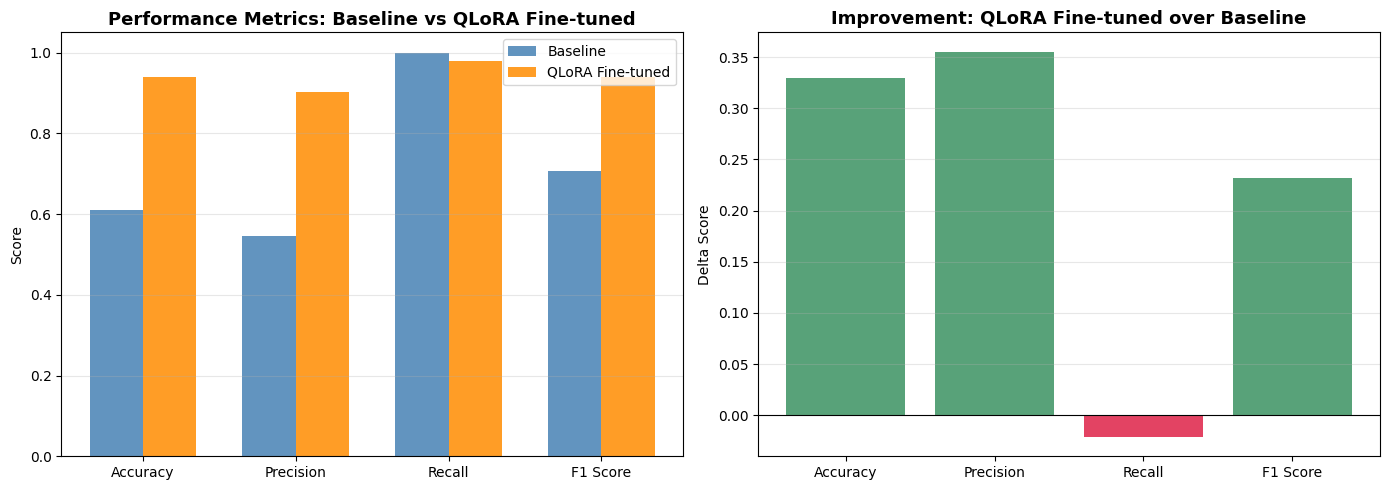

Saved: metrics_comparison.png


In [ ]:
# ============================================================
# SECTION 15: VISUALISATION – METRIC BAR CHART
# Left  panel: Grouped bar chart of all four metrics
# Right panel: Net improvement (QLoRA – Baseline) per metric
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics          = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x                = np.arange(len(metrics))
bar_w            = 0.35

base_vals = [
    baseline_results['accuracy'],
    baseline_results['precision'],
    baseline_results['recall'],
    baseline_results['f1']
]
ft_vals = [
    finetuned_results['accuracy'],
    finetuned_results['precision'],
    finetuned_results['recall'],
    finetuned_results['f1']
]

# Grouped bar chart
axes[0].bar(x - bar_w/2, base_vals, bar_w, label='Baseline',          color='steelblue',  alpha=0.85)
axes[0].bar(x + bar_w/2, ft_vals,   bar_w, label='QLoRA Fine-tuned',  color='darkorange', alpha=0.85)
axes[0].set_title('Performance Metrics: Baseline vs QLoRA Fine-tuned', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Improvement chart
improvements = np.array(ft_vals) - np.array(base_vals)
bar_colours  = ['seagreen' if v >= 0 else 'crimson' for v in improvements]
axes[1].bar(metrics, improvements, color=bar_colours, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Improvement: QLoRA Fine-tuned over Baseline', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Delta Score')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

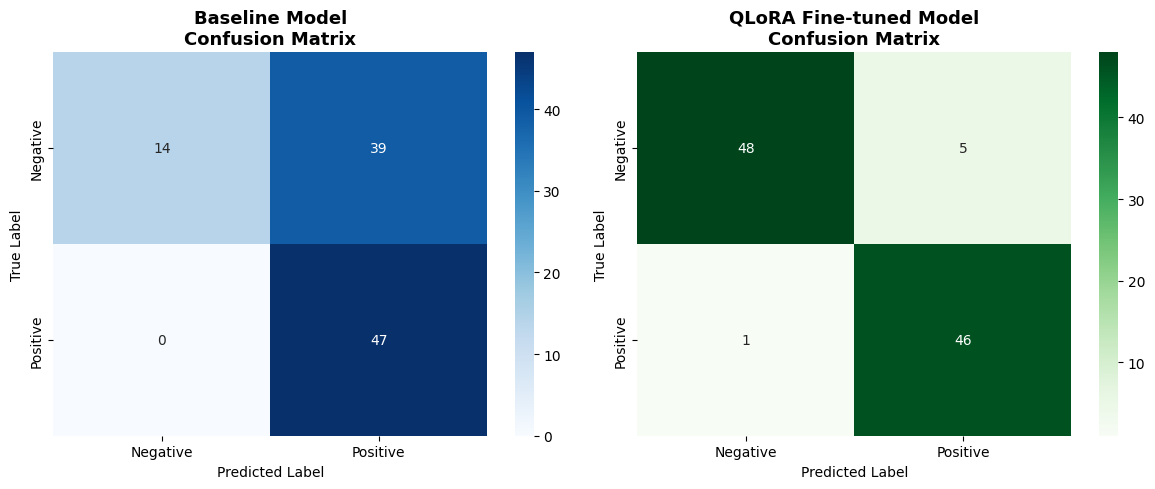

Saved: confusion_matrices.png


In [ ]:
# ============================================================
# SECTION 16: VISUALISATION – CONFUSION MATRICES
# Side-by-side confusion matrices for both models
# ============================================================

cm_baseline  = confusion_matrix(baseline_results['true_labels'],  baseline_results['predictions'])
cm_finetuned = confusion_matrix(finetuned_results['true_labels'], finetuned_results['predictions'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Negative', 'Positive']

sns.heatmap(cm_baseline,  annot=True, fmt='d', cmap='Blues',  ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Baseline Model\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_finetuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('QLoRA Fine-tuned Model\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

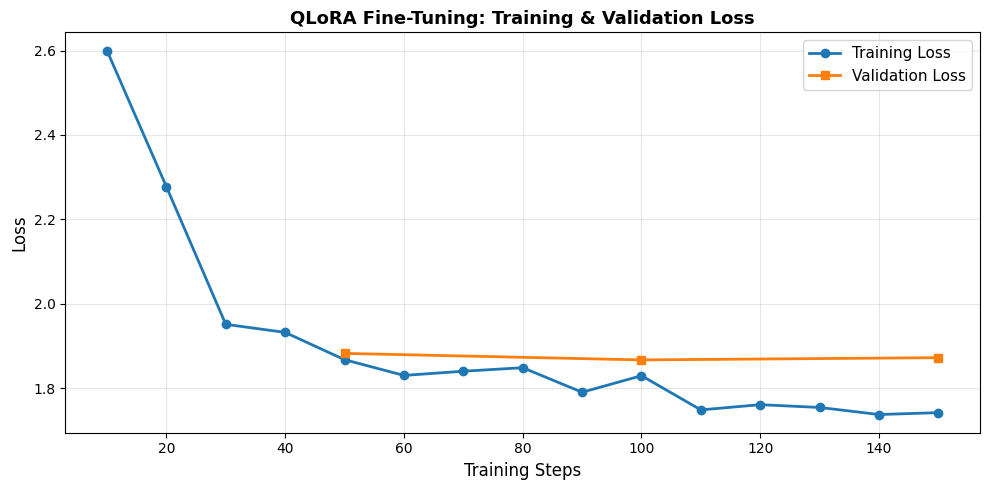

Saved: training_loss_curve.png


In [ ]:
# ============================================================
# SECTION 17: VISUALISATION – TRAINING LOSS CURVE
# Plot training loss (and validation loss if available)
# over the course of fine-tuning steps
# ============================================================

if hasattr(trainer.state, 'log_history') and trainer.state.log_history:
    log_history = trainer.state.log_history

    train_loss  = [e['loss']      for e in log_history if 'loss'      in e]
    train_steps = [e['step']      for e in log_history if 'loss'      in e]
    eval_loss   = [e['eval_loss'] for e in log_history if 'eval_loss' in e]
    eval_steps  = [e['step']      for e in log_history if 'eval_loss' in e]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(train_steps, train_loss, label='Training Loss',   marker='o', linewidth=2)
    if eval_loss:
        ax.plot(eval_steps, eval_loss, label='Validation Loss', marker='s', linewidth=2)
    ax.set_xlabel('Training Steps', fontsize=12)
    ax.set_ylabel('Loss',           fontsize=12)
    ax.set_title('QLoRA Fine-Tuning: Training & Validation Loss', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_loss_curve.png")
else:
    print("No training history found – skipping loss curve plot.")

In [ ]:
# ============================================================
# SECTION 18: QUALITATIVE ANALYSIS – SAMPLE PREDICTIONS
# Compare baseline and fine-tuned model outputs on
# five individual test reviews for a qualitative assessment
# ============================================================

def get_single_prediction(model, tokenizer, text):
    """Return the model's predicted sentiment label for a single review."""
    inference_prompt = (
        f"<|system|>\n{SYSTEM_MSG}</s>\n"
        f"<|user|>\nReview: {text[:500]}</s>\n"
        f"<|assistant|>\nSentiment:"
    )

    inputs = tokenizer(
        inference_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response.split('Sentiment:')[-1].strip()[:30]


# Analyse five diverse test samples
print("=" * 80)
print("QUALITATIVE ANALYSIS – Sample Predictions")
print("=" * 80)

sample_indices = [5, 15, 25, 35, 45]

for idx in sample_indices:
    sample     = test_data[idx]
    text       = sample['text']
    true_label = "positive" if sample['label'] == 1 else "negative"

    base_pred = get_single_prediction(base_model,  tokenizer, text)
    ft_pred   = get_single_prediction(peft_model,  tokenizer, text)

    print(f"\nSample #{idx}")
    print(f"  Review excerpt         : {text[:200]}...")
    print(f"  Ground truth           : {true_label}")
    print(f"  Baseline prediction    : {base_pred}")
    print(f"  Fine-tuned prediction  : {ft_pred}")
    print("-" * 80)

QUALITATIVE ANALYSIS – Sample Predictions

Sample #5
  Review excerpt         : After a very long time Marathi cinema has come with some good movie.This movie is one of the best Marathi movies ever made. It shows how a old grandfather tries to save his grandsons eye. He tries eve...
  Ground truth           : positive
  Baseline prediction    : positive
  Fine-tuned prediction  : positive
--------------------------------------------------------------------------------

Sample #15
  Review excerpt         : I'm 15, usually not kids my age usually watch these old classic movies. But this is one of my favorites. I was totally addicted after watching it for the first time. It's really good if u think about ...
  Ground truth           : positive
  Baseline prediction    : positive
  Fine-tuned prediction  : positive
--------------------------------------------------------------------------------

Sample #25
  Review excerpt         : "In Love and War" is a simple feel-good TV-film, and sho

In [ ]:
# ============================================================
# SECTION 19: MEMORY CLEANUP
# Release GPU memory after evaluation is complete
# ============================================================

del peft_model
del base_model
del trainer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU memory released.")
print("\n--- Project Summary ---")
print("Model    : TinyLlama/TinyLlama-1.1B-Chat-v1.0")
print("Task     : Sentiment Analysis (IMDB binary)")
print("Method   : QLoRA (Parameter-Efficient Fine-Tuning)")
print("\nGenerated output files:")
print("  metrics_comparison.png")
print("  confusion_matrices.png")
print("  training_loss_curve.png")
print(f"  Adapter weights  -> {SAVE_DIR}/")

GPU memory released.

--- Project Summary ---
Model    : TinyLlama/TinyLlama-1.1B-Chat-v1.0
Task     : Sentiment Analysis (IMDB binary)
Method   : QLoRA (Parameter-Efficient Fine-Tuning)

Generated output files:
  metrics_comparison.png
  confusion_matrices.png
  training_loss_curve.png
  Adapter weights  -> ./tinyllama_qlora_sentiment_final/


In [ ]:
# ============================================================
# SECTION 20: EXPORT – ZIP ADAPTER FOR DOWNLOAD
# Compress the saved adapter directory for easy download
# from Google Colab to local machine
# ============================================================

!zip -r tinyllama_qlora_sentiment_final.zip /content/tinyllama_qlora_sentiment_final
print("Archive created: tinyllama_qlora_sentiment_final.zip")

  adding: content/tinyllama_qlora_sentiment_final/ (stored 0%)
  adding: content/tinyllama_qlora_sentiment_final/adapter_config.json (deflated 58%)
  adding: content/tinyllama_qlora_sentiment_final/README.md (deflated 65%)
  adding: content/tinyllama_qlora_sentiment_final/tokenizer.json (deflated 85%)
  adding: content/tinyllama_qlora_sentiment_final/tokenizer_config.json (deflated 46%)
  adding: content/tinyllama_qlora_sentiment_final/chat_template.jinja (deflated 60%)
  adding: content/tinyllama_qlora_sentiment_final/adapter_model.safetensors (deflated 54%)
Archive created: tinyllama_qlora_sentiment_final.zip
